In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVR
from sklearn.preprocessing import RobustScaler
from sklearn.tree import DecisionTreeRegressor, plot_tree
from sklearn.model_selection import  GridSearchCV
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.utils import resample
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import mean_squared_error, accuracy_score, confusion_matrix, classification_report
from sklearn.ensemble import RandomForestRegressor

# Cargar los datos correctamente
from google.colab import files
uploaded = files.upload()

# Intenta detectar delimitador automáticamente
try:
    df = pd.read_csv('Anexo ET_demo_round_traces_2022.csv', low_memory=False)
except pd.errors.ParserError:
    df = pd.read_csv('Anexo ET_demo_round_traces_2022.csv', sep=';', low_memory=False)

# Eliminar columna de índice innecesaria si existe
if 'Unnamed: 0' in df.columns:
    df = df.drop(columns=['Unnamed: 0'])
# Vista previa del DataFrame
df.head()

Saving Anexo ET_demo_round_traces_2022.csv to Anexo ET_demo_round_traces_2022 (1).csv


,Map,Team,InternalTeamId,MatchId,RoundId,RoundWinner,MatchWinner,Survived,AbnormalMatch,TimeAlive,...,RoundKills,RoundAssists,RoundHeadshots,RoundFlankKills,RoundStartingEquipmentValue,TeamStartingEquipmentValue,MatchKills,MatchFlankKills,MatchAssists,MatchHeadshots
0,de_inferno,Terrorist,1,4,1,False,True,False,False,51.120.248.995.704.500,...,0,0,0,0,750,4400,0,0,0,0
1,de_inferno,Terrorist,1,4,1,False,True,False,False,4.348.662.552.266.170,...,0,0,0,0,800,4400,0,0,0,0
2,de_inferno,Terrorist,1,4,1,False,True,False,False,3.735.469.847.054.540,...,0,0,0,0,1000,4400,0,0,0,0
3,de_inferno,Terrorist,1,4,1,False,True,False,False,4.767.886.136.441.470,...,0,0,0,0,850,4400,0,0,0,0
4,de_inferno,Terrorist,1,4,1,False,True,True,False,5.312.251.089.027.310,...,0,0,0,0,1000,4400,0,0,0,0


In [ ]:
# Nombres correctos de las columnas
column_names = [
    'PlayerId', 'Map', 'Team', 'InternalTeamId', 'MatchId', 'RoundId', 'RoundWinner',
    'MatchWinner', 'Survived', 'AbnormalMatch', 'TimeAlive', 'TravelledDistance',
    'RLethalGrenadesThrown', 'RNonLethalGrenadesThrown', 'PrimaryAssaultRifle',
    'PrimarySniperRifle', 'PrimaryHeavy', 'PrimarySMG', 'PrimaryPistol', 'FirstKillTime',
    'RoundKills', 'RoundAssists', 'RoundHeadshots', 'RoundFlankKills',
    'RoundStartingEquipmentValue', 'TeamStartingEquipmentValue', 'MatchKills',
    'MatchFlankKills', 'MatchAssists', 'MatchHeadshots'
]



# Columnas a convertir
cols_to_numeric = [
    'TimeAlive', 'TravelledDistance', 'RoundAssists', 'RoundHeadshots',
    'RoundStartingEquipmentValue', 'RoundKills', 'MatchKills', 'TeamStartingEquipmentValue'
]

# Convertir columnas a numéricas
for col in cols_to_numeric:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='coerce')
    else:
        print(f"Warning: Column '{col}' not found in DataFrame.")

# Eliminar filas con nulos en variables clave
df = df.dropna(subset=['MatchKills', 'TeamStartingEquipmentValue'])

# Convertir 'Survived' a booleano si existe
if 'Survived' in df.columns:
    df['Survived'] = df['Survived'].astype(bool)


# Resumen estadístico
cols_to_describe = [col for col in cols_to_numeric if col in df.columns]
print("\nResumen estadístico:")
print(df[cols_to_describe].describe())



Resumen estadístico:
       TimeAlive  TravelledDistance  RoundAssists  RoundHeadshots  \
count  70.000000               70.0          70.0            70.0   
mean    0.514286                0.0           0.0             0.0   
std     3.020427                0.0           0.0             0.0   
min     0.000000                0.0           0.0             0.0   
25%     0.000000                0.0           0.0             0.0   
50%     0.000000                0.0           0.0             0.0   
75%     0.000000                0.0           0.0             0.0   
max    18.000000                0.0           0.0             0.0   

       RoundStartingEquipmentValue  RoundKills  MatchKills  \
count                    70.000000        70.0   70.000000   
mean                   1775.000000         0.0    3.500000   
std                    2097.216064         0.0    4.373007   
min                       0.000000         0.0    0.000000   
25%                     200.000000         0.0

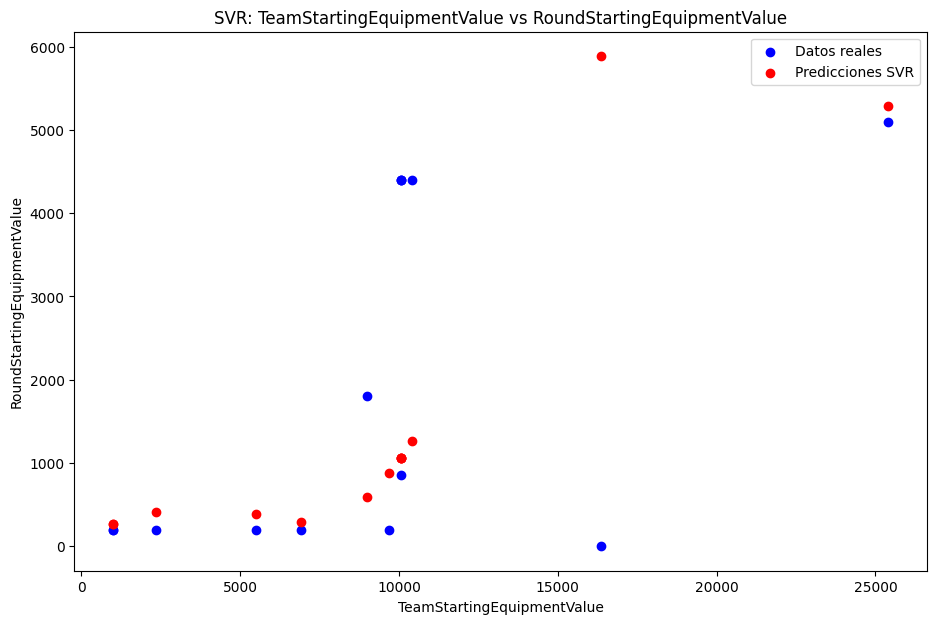

MSE: 5719380.0728
RMSE: 2391.5225
MAE: 1568.0939
R²: -0.40


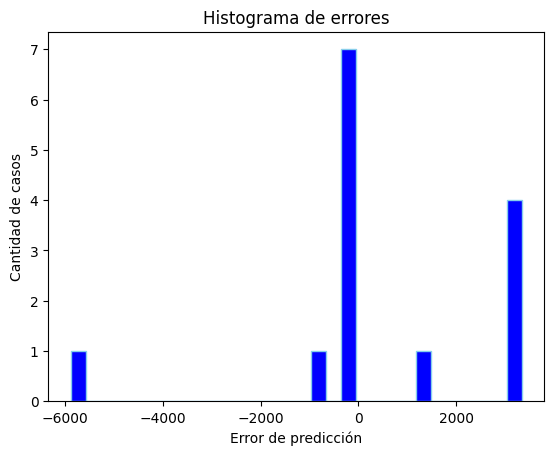

In [ ]:
# Selección de características y objetivo
features = df[['TeamStartingEquipmentValue']].values  # Predictor
target = df['RoundStartingEquipmentValue'].values     # Variable a predecir

# División de datos en conjunto de entrenamiento y prueba
X_train, X_val, y_train, y_val = train_test_split(features, target, test_size=0.2, random_state=42)

# Normalización
scaler_features = RobustScaler(quantile_range=(25, 75))
scaler_target = RobustScaler()

X_train_norm = scaler_features.fit_transform(X_train)
X_val_norm = scaler_features.transform(X_val)

y_train_norm = scaler_target.fit_transform(y_train.reshape(-1, 1)).ravel()

# Definición y ajuste del modelo SVM
modelo_svr = SVR(kernel='rbf', C=1.0, epsilon=0.05)
modelo_svr.fit(X_train_norm, y_train_norm)

# Realizar predicciones y volver a la escala original
y_val_pred_norm = modelo_svr.predict(X_val_norm)
y_val_pred = scaler_target.inverse_transform(y_val_pred_norm.reshape(-1, 1)).ravel()

# Gráfica de comparación entre valores reales y predicciones
plt.figure(figsize=(11,7))
plt.scatter(X_val, y_val, color='blue', label='Datos reales')
plt.scatter(X_val, y_val_pred, color='red', label='Predicciones SVR')
plt.title('SVR: TeamStartingEquipmentValue vs RoundStartingEquipmentValue')
plt.xlabel('TeamStartingEquipmentValue')
plt.ylabel('RoundStartingEquipmentValue')
plt.legend()
plt.show()

# Cálculo de métricas para evaluar el modelo
error_cuadratico_medio = mean_squared_error(y_val, y_val_pred)
raiz_error_cuadratico = np.sqrt(error_cuadratico_medio)
error_absoluto_medio = mean_absolute_error(y_val, y_val_pred)
coef_r2 = r2_score(y_val, y_val_pred)

print(f"MSE: {error_cuadratico_medio:.4f}")
print(f"RMSE: {raiz_error_cuadratico:.4f}")
print(f"MAE: {error_absoluto_medio:.4f}")
print(f"R²: {coef_r2:.2f}")

# Histograma para visualizar la distribución de errores
diferencias = y_val - y_val_pred.flatten()

plt.hist(diferencias, bins=30, color='blue', edgecolor='skyblue')
plt.title('Histograma de errores')
plt.xlabel('Error de predicción')
plt.ylabel('Cantidad de casos')
plt.show()
